In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Cambiar al directorio de descargas
os.chdir('C:/Users/Usuario/Downloads')

# Encoding corregido para lectura de Producto.csv
# ======================

# Leer archivo de ventas (funciona con UTF-8)
ventas_df = pd.read_csv('Ventas_unificada_ordenado.csv')

# Leer archivo de productos con encoding 'latin1' (más común en Windows para español)
# OPCIÓN 1: Usar latin1
producto_df = pd.read_csv('Producto.csv', encoding='latin1')
print("="*80)
print("ARCHIVOS LEÍDOS CORRECTAMENTE")
print("="*80)
print(f"VENTAS - Shape: {ventas_df.shape}")
print(ventas_df.head())
print(f"\nPRODUCTO - Shape: {producto_df.shape}")
print(producto_df.head())


ARCHIVOS LEÍDOS CORRECTAMENTE
VENTAS - Shape: (13035, 4)
      BRAND              ITEM  TOTAL_UNIT_AVG_WEEKLY_SALES              REGION
0     SHOUT       46500222979                            1  TOTAL AUTOS AREA 4
1    VANISH  7501058796950BP1                            1  TOTAL AUTOS AREA 1
2     SHOUT       46500022692                            1  TOTAL AUTOS AREA 6
3  CLORALEX          75000592                            1  TOTAL AUTOS AREA 6
4  CLORALEX  7501025450984BP2                            1  TOTAL AUTOS AREA 4

PRODUCTO - Shape: (505, 9)
  MANUFACTURER     BRAND      ITEM  \
0   INDS. ALEN  CLORALEX  75000592   
1   INDS. ALEN  CLORALEX  75000608   
2   INDS. ALEN  CLORALEX  75000615   
3   INDS. ALEN  CLORALEX  75000622   
4   INDS. ALEN  CLORALEX  75000639   

                                    ITEM_DESCRIPTION  CATEGORY  ATTR1  ATTR2  \
0  CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...         1  CLORO  CLORO   
1  CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...

In [3]:
# a) Mapeo de columnas
print("\n" + "="*80)
print("APLICANDO MAPEOS")
print("="*80)

# Mapeo para BRAND en Ventas
brand_mapping = {
    'BANDERA': 1,
    'BCLORHADA': 2,
    'CLORALEX': 3,
    'CLOROX': 4,
    'LYSOL': 5,
    'SHOUT': 6,
    'TIDE': 7,
    'VANISH': 8
}

# Mapeo para REGION en Ventas
region_mapping = {
    'TOTAL AUTOS AREA 1': 1,
    'TOTAL AUTOS AREA 2': 2,
    'TOTAL AUTOS AREA 3': 3,
    'TOTAL AUTOS AREA 4': 4,
    'TOTAL AUTOS AREA 5': 5,
    'TOTAL AUTOS AREA 6': 6,
    'TOTAL AUTOS SCANNING MEXICO': 7
}

# Aplicar mapeos
ventas_df['BRAND_CODE'] = ventas_df['BRAND'].map(brand_mapping)
ventas_df['REGION_CODE'] = ventas_df['REGION'].map(region_mapping)

# Mapeo para FORMAT en Producto
format_mapping = {
    'BARRA': 1,
    'GEL': 2,
    'LIQUIDO': 3,
    'POLVO': 4,
    'TOALLAS': 5
}

# Mapeo para ATTR1 en Producto
attr1_mapping = {
    'CLORO': 1,
    'PRELAVADOR': 2,
    'SAFE BLEACH': 3,
    'SANITIZANTE': 4
}

# Aplicar mapeos en producto_df
producto_df['FORMAT_CODE'] = producto_df['FORMAT'].map(format_mapping)
producto_df['ATTR1_CODE'] = producto_df['ATTR1'].map(attr1_mapping)

print(" Mapeos aplicados ")

# c) Análisis de ventas
# ======================

# Filtrar solo las marcas de interés
marcas_interes = ['LYSOL', 'TIDE', 'VANISH']
ventas_filtradas = ventas_df[ventas_df['BRAND'].isin(marcas_interes)].copy()

print(f"\nRegistros para marcas seleccionadas: {len(ventas_filtradas)}")

# Agrupar por ITEM y REGION
ventas_agrupadas = ventas_filtradas.groupby(['ITEM', 'REGION', 'BRAND']).agg({
    'TOTAL_UNIT_AVG_WEEKLY_SALES': 'sum'
}).reset_index()

ventas_agrupadas.rename(columns={'TOTAL_UNIT_AVG_WEEKLY_SALES': 'TOTAL_SALES'}, inplace=True)

# Calcular promedio por marca
promedio_marca = ventas_filtradas.groupby('BRAND').agg({
    'TOTAL_UNIT_AVG_WEEKLY_SALES': 'mean'
}).reset_index()
promedio_marca.rename(columns={'TOTAL_UNIT_AVG_WEEKLY_SALES': 'AVG_WEEKLY_SALES'}, inplace=True)

print("\nPROMEDIO DE VENTAS SEMANALES POR MARCA:")
print(promedio_marca)

# Enriquecer con datos de producto
producto_clean = producto_df[['ITEM', 'ATTR1', 'FORMAT', 'ITEM_DESCRIPTION']].drop_duplicates(subset=['ITEM'])

ventas_enriquecidas = ventas_agrupadas.merge(
    producto_clean, 
    on='ITEM', 
    how='left'
)

print("\nTABLA ENRIQUECIDA:")
print(ventas_enriquecidas.head(10))


APLICANDO MAPEOS
 Mapeos aplicados 

Registros para marcas seleccionadas: 6950

PROMEDIO DE VENTAS SEMANALES POR MARCA:
    BRAND  AVG_WEEKLY_SALES
0   LYSOL          2.580000
1    TIDE          2.177102
2  VANISH          3.393096

TABLA ENRIQUECIDA:
               ITEM                       REGION   BRAND  TOTAL_SALES  \
0       19200958714           TOTAL AUTOS AREA 2   LYSOL            2   
1       19200958714  TOTAL AUTOS SCANNING MEXICO   LYSOL            2   
2       37000018704           TOTAL AUTOS AREA 1    TIDE          121   
3       37000018704           TOTAL AUTOS AREA 2    TIDE          134   
4       37000018704           TOTAL AUTOS AREA 3    TIDE          209   
5       37000018704           TOTAL AUTOS AREA 4    TIDE          142   
6       37000018704           TOTAL AUTOS AREA 5    TIDE          234   
7       37000018704           TOTAL AUTOS AREA 6    TIDE          209   
8       37000018704  TOTAL AUTOS SCANNING MEXICO    TIDE          168   
9  7501058782694B


REGRESIÓN MÚLTIPLE LINEAL

R² Score (Prueba): -0.0184
RMSE (Prueba): 223.30
MAE (Prueba): 126.29

PRONÓSTICO PROMEDIO POR MARCA:
BRAND
VANISH    224.695303
TIDE      215.956883
LYSOL     207.218462
Name: FORECAST_SALES, dtype: float64


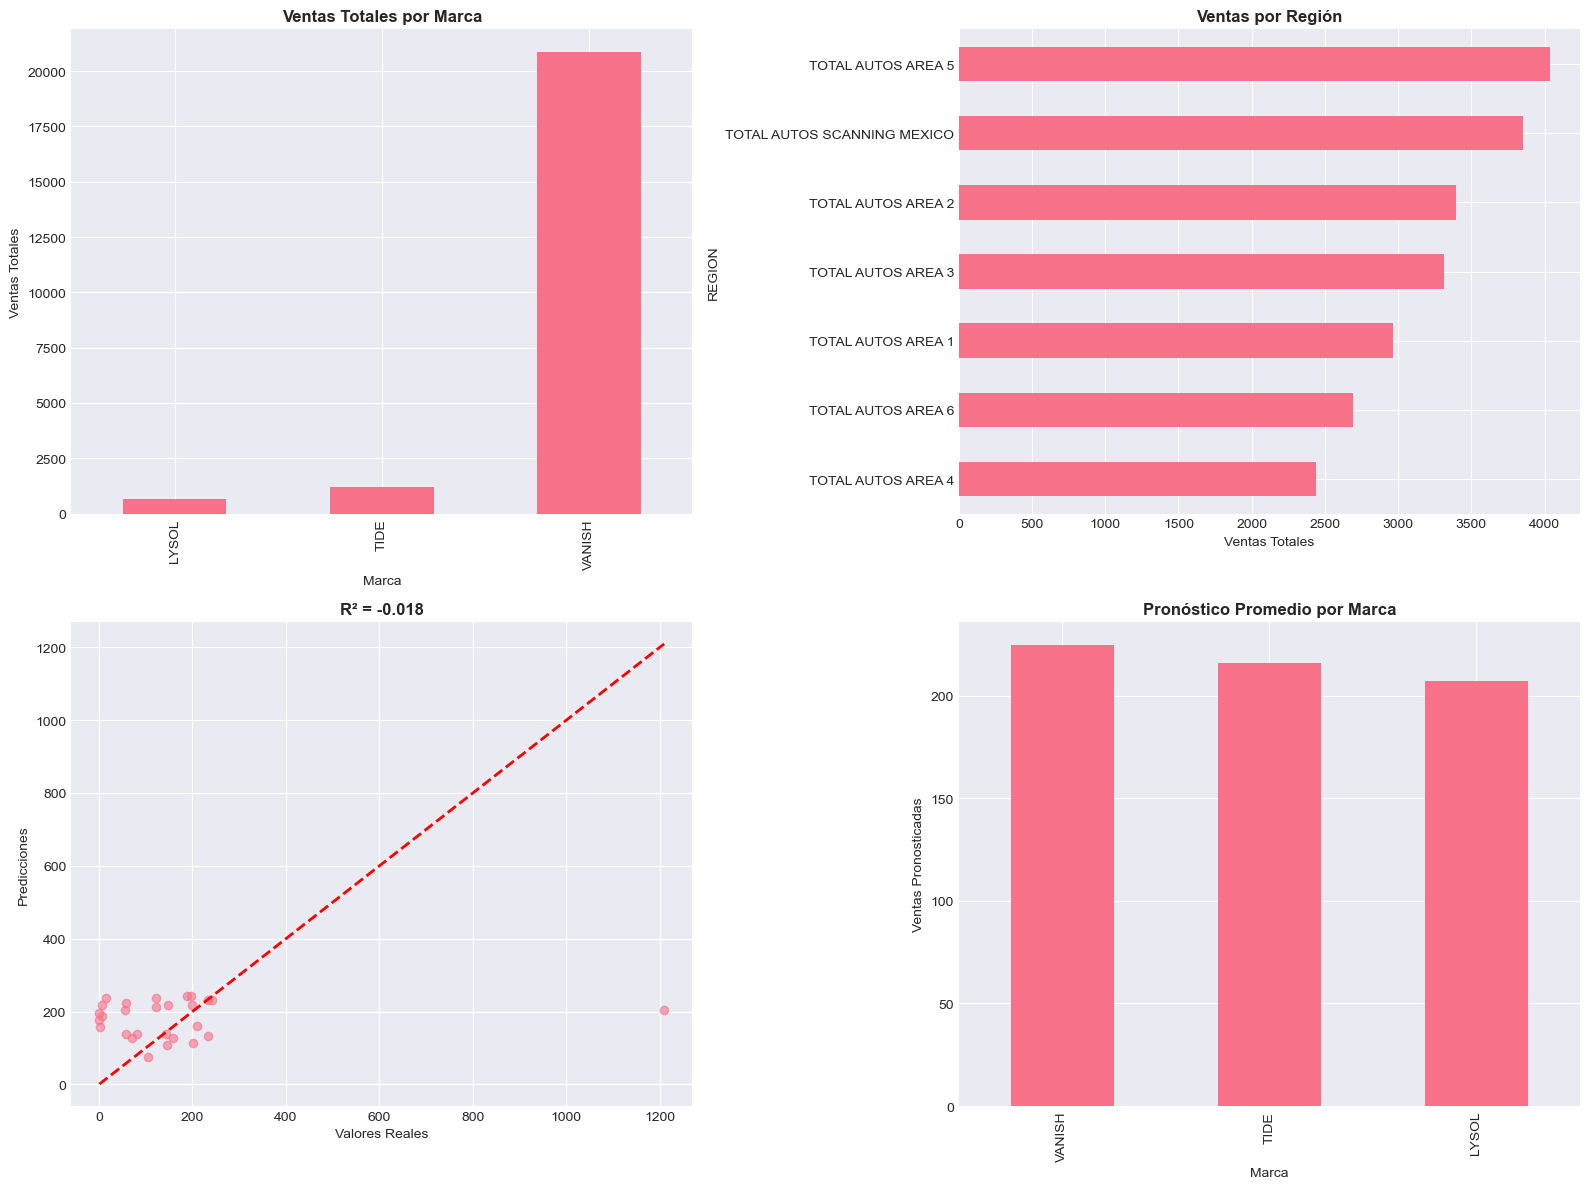

In [4]:
# d) Regresión Múltiple Lineal
print("\n" + "="*80)
print("REGRESIÓN MÚLTIPLE LINEAL")
print("="*80)

# Preparar datos para regresión
regression_data = ventas_enriquecidas.dropna(subset=['ATTR1', 'FORMAT']).copy()

# Codificar variables categóricas
le_brand = LabelEncoder()
le_region = LabelEncoder()
le_attr = LabelEncoder()
le_format = LabelEncoder()

regression_data['BRAND_ENC'] = le_brand.fit_transform(regression_data['BRAND'])
regression_data['REGION_ENC'] = le_region.fit_transform(regression_data['REGION'])
regression_data['ATTR1_ENC'] = le_attr.fit_transform(regression_data['ATTR1'])
regression_data['FORMAT_ENC'] = le_format.fit_transform(regression_data['FORMAT'])

# Variables independientes
features = ['BRAND_ENC', 'REGION_ENC', 'ATTR1_ENC', 'FORMAT_ENC']
X = regression_data[features]
y = regression_data['TOTAL_SALES']

# Dividir y entrenar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred_test = model.predict(X_test)

# Métricas
print(f"\nR² Score (Prueba): {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE (Prueba): {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"MAE (Prueba): {mean_absolute_error(y_test, y_pred_test):.2f}")

# Pronóstico
forecast_results = []
for brand in regression_data['BRAND'].unique():
    for region in regression_data['REGION'].unique():
        brand_enc = le_brand.transform([brand])[0]
        region_enc = le_region.transform([region])[0]
        attr_enc = regression_data['ATTR1_ENC'].mode()[0]
        format_enc = regression_data['FORMAT_ENC'].mode()[0]
        
        forecast_X = np.array([[brand_enc, region_enc, attr_enc, format_enc]])
        forecast_sales = model.predict(forecast_X)[0]
        
        forecast_results.append({
            'BRAND': brand,
            'REGION': region,
            'FORECAST_SALES': forecast_sales
        })

forecast_df = pd.DataFrame(forecast_results)
forecast_by_brand = forecast_df.groupby('BRAND')['FORECAST_SALES'].mean().sort_values(ascending=False)

print("\nPRONÓSTICO PROMEDIO POR MARCA:")
print(forecast_by_brand)


# Gráficos
# ======================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Ventas por marca
ax1 = axes[0, 0]
ventas_por_marca = ventas_enriquecidas.groupby('BRAND')['TOTAL_SALES'].sum()
ventas_por_marca.plot(kind='bar', ax=ax1)
ax1.set_title('Ventas Totales por Marca', fontweight='bold')
ax1.set_xlabel('Marca')
ax1.set_ylabel('Ventas Totales')

# Gráfico 2: Ventas por región
ax2 = axes[0, 1]
ventas_por_region = ventas_enriquecidas.groupby('REGION')['TOTAL_SALES'].sum().sort_values(ascending=True)
ventas_por_region.plot(kind='barh', ax=ax2)
ax2.set_title('Ventas por Región', fontweight='bold')
ax2.set_xlabel('Ventas Totales')

# Gráfico 3: Predicciones vs Reales
ax3 = axes[1, 0]
ax3.scatter(y_test, y_pred_test, alpha=0.6)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_xlabel('Valores Reales')
ax3.set_ylabel('Predicciones')
ax3.set_title(f'R² = {r2_score(y_test, y_pred_test):.3f}', fontweight='bold')

# Gráfico 4: Pronóstico por marca
ax4 = axes[1, 1]
forecast_by_brand.plot(kind='bar', ax=ax4)
ax4.set_title('Pronóstico Promedio por Marca', fontweight='bold')
ax4.set_xlabel('Marca')
ax4.set_ylabel('Ventas Pronosticadas')

plt.tight_layout()
plt.show()
